# Chromosome, Replicate 1 Scripting

Create a script to run the deconvolution on each replicate. This notebook will test the script.


In [119]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [120]:
from pipeline.fit_replication_profiles import main
from src.utils import mkdir_safe

output_directory = "output/prototype_pipeline_subset_stage2/"


In [383]:
from pipeline.fit_replication_profiles import main as fit_replication_profile
from src.utils import print_fl
from src.config import load_default_chrom_configs, load_cloccs_configs
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.optimize_H import create_bounds_params_from_config

cold_start = False
chrom = 4
replicate = 1
num_epochs = 0
config = None
config, _ = load_cloccs_configs()

np.random.seed(123)

update_params_df, replication_deconvolver, optimizer = fit_replication_profile(chrom=chrom, 
    replicate=replicate, num_epochs=num_epochs, output_directory=output_directory, 
    save=False, config=config,
    learn_subset_parameters=[])

Loading MNase data
Omit windows with less than 75% read coverage.
Running initial iterations...
Deconvolving 702 regions
Initializing B using timepoint 0
Subsetting the cell cycle parameters to learn:  ['mu0', 'sigma0', 'gamma2']
[0] 00:00:01.501, rn=0.005223035439532049
[1] 00:00:03.003, rn=0.004421633715921432
[2] 00:00:04.478, rn=0.004116755548242992
[3] 00:00:05.959, rn=0.003979478567510776
[4] 00:00:07.595, rn=0.0039107991597480875
[5] 00:00:09.119, rn=0.00387283123780201
[6] 00:00:10.698, rn=0.003854996021272069
[7] 00:00:12.242, rn=0.003848576709737828
[8] 00:00:13.813, rn=0.0038452131989941017
[9] 00:00:15.498, rn=0.0038425721981598963
[10] 00:00:17.110, rn=0.00383867824231144
[11] 00:00:18.717, rn=0.0038361986269388124
[12] 00:00:20.491, rn=0.0038348965277576544
[13] 00:00:22.279, rn=0.0038339358263105904
[14] 00:00:23.988, rn=0.003833131862879404
[15] 00:00:25.634, rn=0.0038325772061364245
[16] 00:00:27.416, rn=0.0038321608890489996
[17] 00:00:29.182, rn=0.003832144688644719


In [416]:
replication_deconvolver.iterative_deconvolution_updates(30)

[0] 00:00:01.266, rn=0.005749524148748396
[1] 00:00:02.479, rn=0.004504649589590387
[2] 00:00:03.760, rn=0.003910116948948018
[3] 00:00:05.056, rn=0.0036301857621241457
[4] 00:00:06.285, rn=0.003489367852926218
[5] 00:00:07.529, rn=0.0034193850910845046
[6] 00:00:08.829, rn=0.0033829078703688786
[7] 00:00:10.044, rn=0.0033658923390208753
[8] 00:00:11.446, rn=0.0033563491195444015
[9] 00:00:12.815, rn=0.00335194100723517
[10] 00:00:14.171, rn=0.0033493670159383798
[11] 00:00:15.384, rn=0.003346859613696778
[12] 00:00:16.828, rn=0.003345193351926
[13] 00:00:18.096, rn=0.0033444136868118275
[14] 00:00:19.336, rn=0.003343958294944311
[15] 00:00:20.646, rn=0.003343692600477761
[16] 00:00:21.917, rn=0.003343288716980659
[17] 00:00:23.267, rn=0.0033431027021641785
[18] 00:00:24.651, rn=0.003342898340042684
[19] 00:00:25.952, rn=0.0033426936097561318
[20] 00:00:27.283, rn=0.0033424758607179467
[21] 00:00:28.568, rn=0.003342473126972795
[22] 00:00:29.733, rn=0.0033424731310778494
[23] 00:00:30.

Text(0.5, 1.0, 'Average copy number')

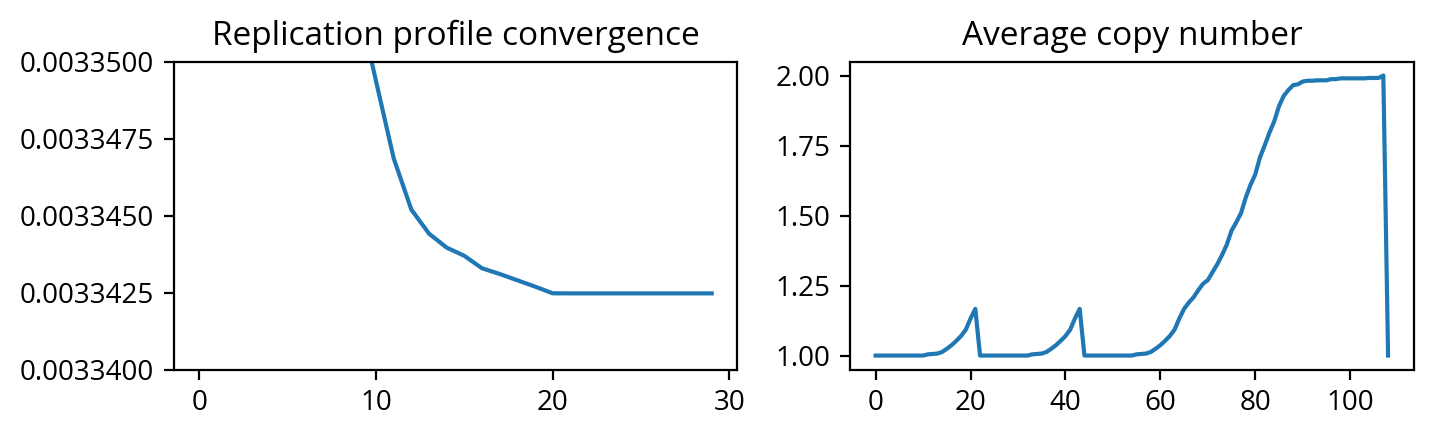

In [417]:
plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
plt.plot(replication_deconvolver.result.iterative_update_rns)
plt.ylim(0.00334, 0.00335)
plt.title("Replication profile convergence")
plt.subplot(1, 2, 2)
plt.plot(replication_deconvolver.F.mean(1))
plt.title("Average copy number")

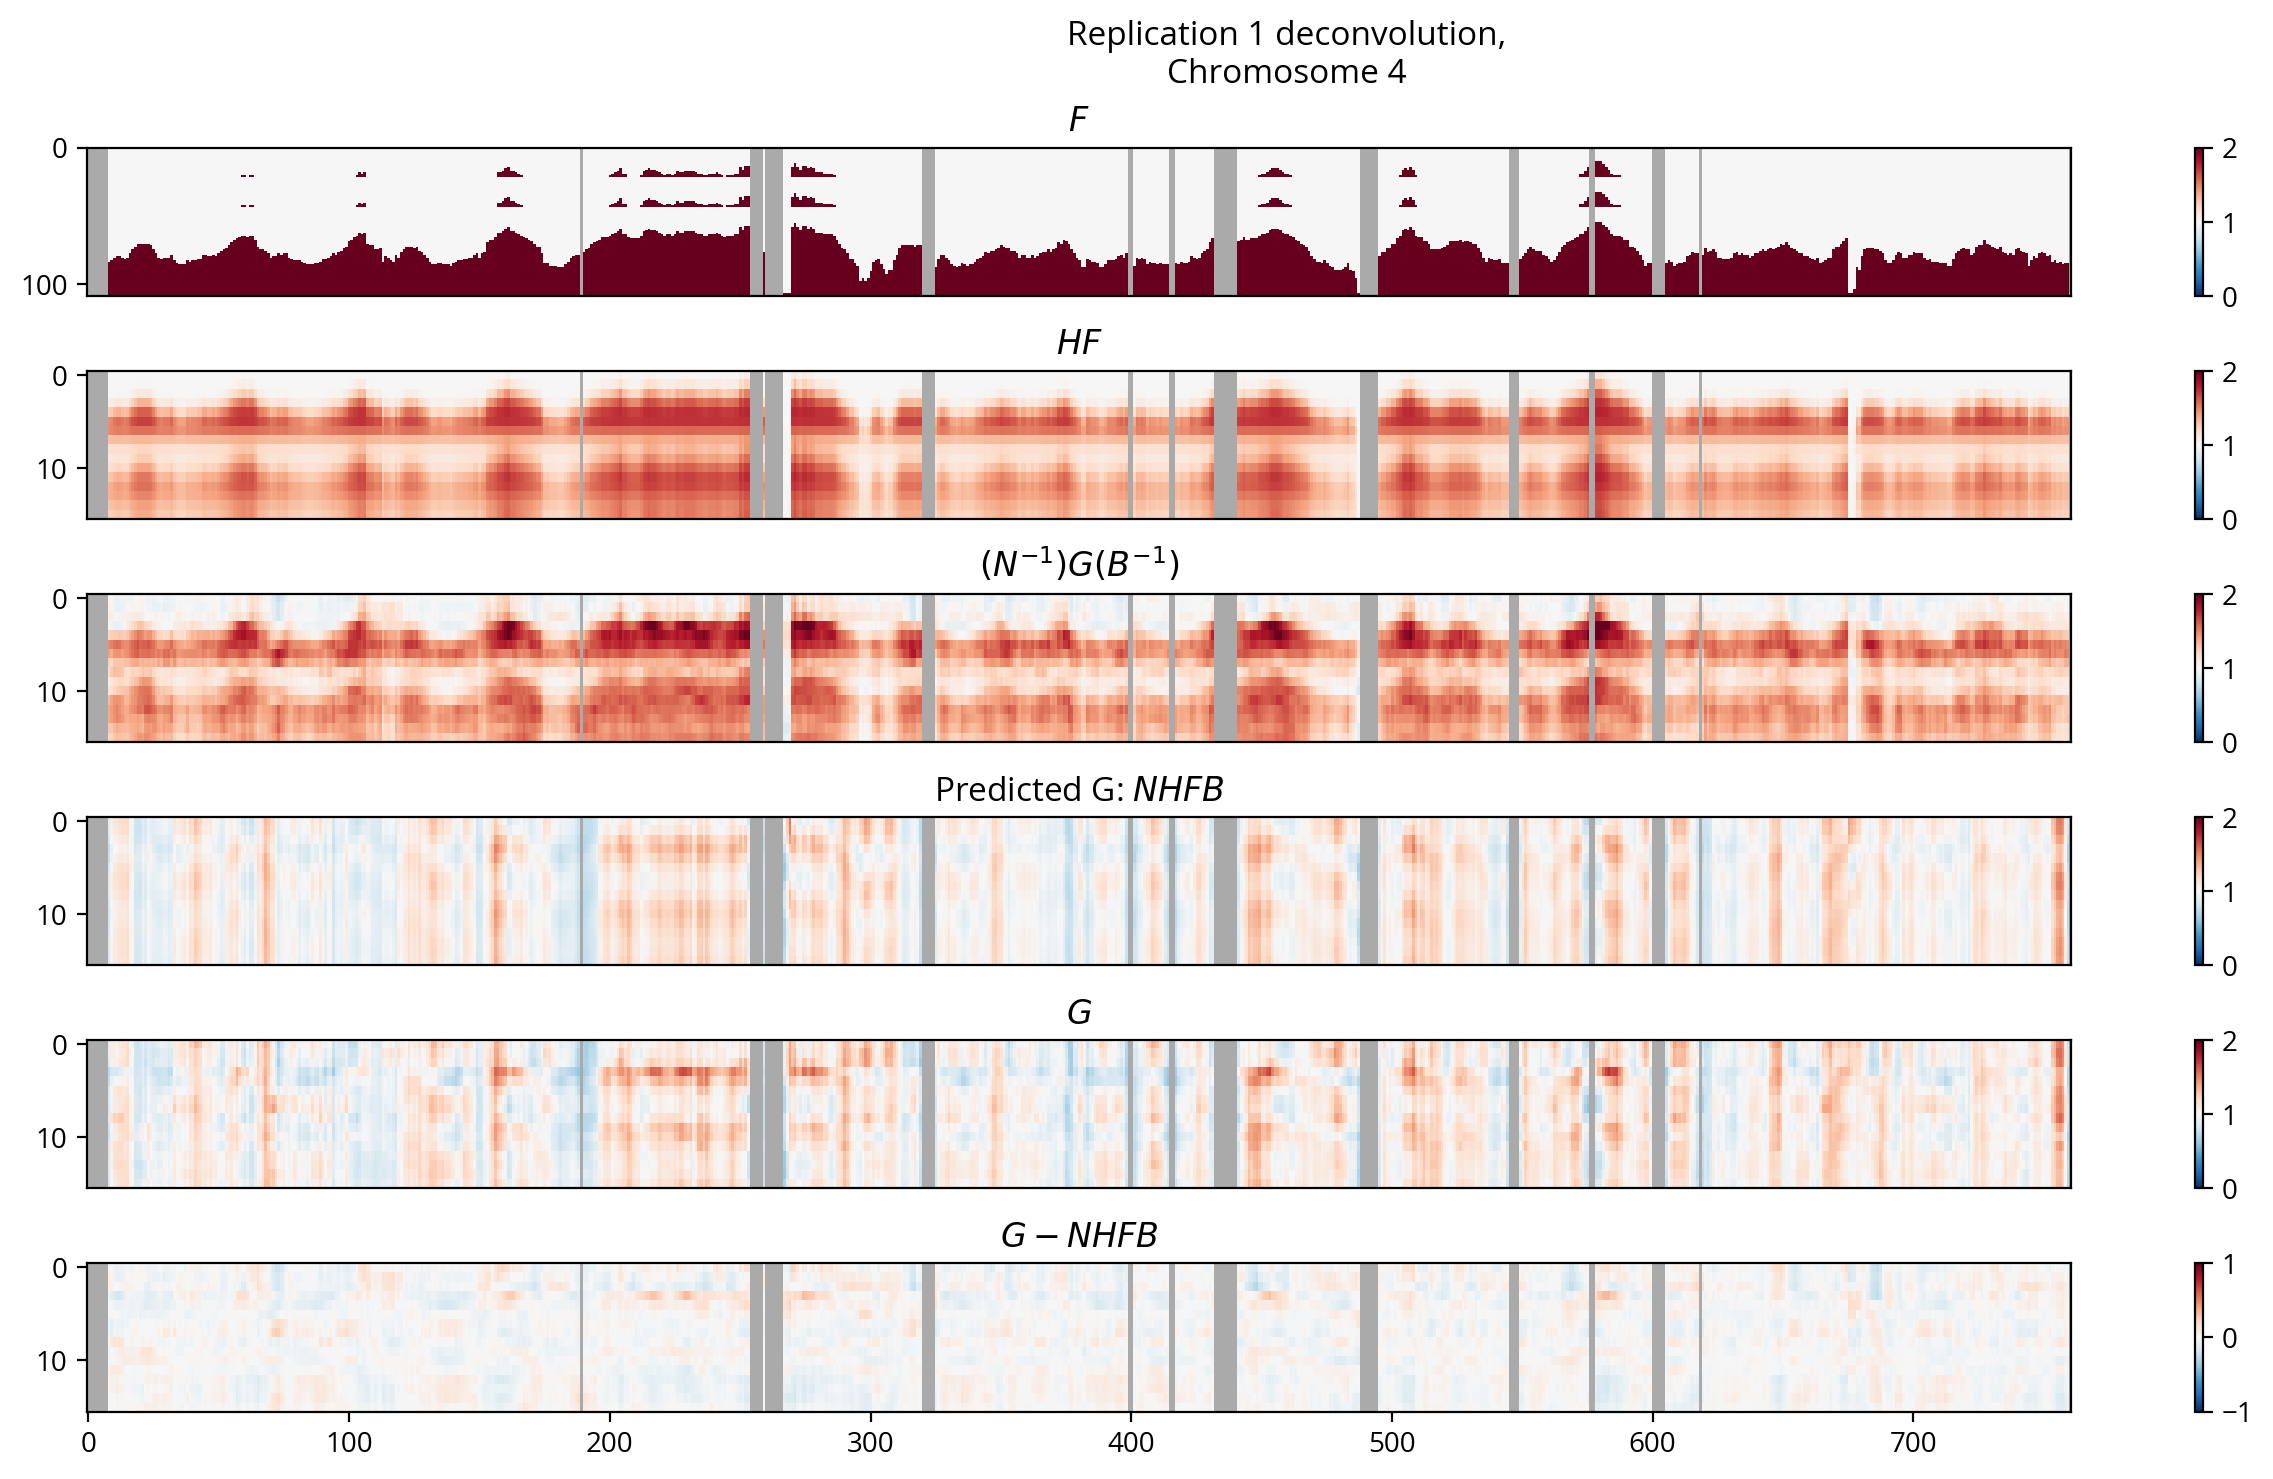

In [418]:
fig = replication_deconvolver.plot_heatmaps(figsize=(16, 8))